# Inspect Milan forecasting outputs

Run `python run.py all` on the complete source data first. This notebook reads results; it does not train models or contain preset findings.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RESULTS = ROOT / "results" / "results"
FIGURES = ROOT / "figures" / "figures"
PROCESSED = ROOT / "data" / "processed"
print("Project:", ROOT)
print("Full-data output available:", (RESULTS / "results.csv").exists())

Project: D:\Milan_Traffic_Forecasting_Project\milan-traffic-forecast
Full-data output available: True


In [2]:
if (PROCESSED / "manifest.json").exists():
    manifest = json.loads((PROCESSED / "manifest.json").read_text())
    print("Raw file count:", len(manifest["files"]))
    print("Top three squares:", manifest["top3"])
    print("Evaluation squares:", manifest["evaluation_areas"])
    print("Coverage:", manifest["coverage"])
    print("Measured memory comparison:", manifest["memory_probe"])
else:
    print("Run data preparation first.")

Raw file count: 61
Top three squares: [5161, 5059, 5259]
Evaluation squares: [5161, 4159, 4556]
Coverage: {'5161': {'observed_intervals': 8784, 'missing_intervals': 0}, '5059': {'observed_intervals': 8784, 'missing_intervals': 0}, '5259': {'observed_intervals': 8784, 'missing_intervals': 0}, '4159': {'observed_intervals': 8784, 'missing_intervals': 0}, '4556': {'observed_intervals': 8784, 'missing_intervals': 0}}
Measured memory comparison: {'file': 'sms-call-internet-mi-2013-11-01.txt', 'rows': 100000, 'full_8_column_bytes': 6400132, 'selected_3_column_bytes': 2000132, 'reduction_percent': 68.748582060495}


In [3]:
if (RESULTS / "results.csv").exists():
    scores = pd.read_csv(RESULTS / "results.csv")
    display(scores[["area", "model", "mae", "mape_percent", "rmse", "final_fit_seconds", "week_inference_seconds"]])
    for area, group in scores.groupby("area"):
        print("Area", area)
        display(group[["model", "mae", "mape_percent", "rmse", "n", "mape_nonzero_count"]])
else:
    print("Run model training first.")

,area,model,mae,mape_percent,rmse,final_fit_seconds,week_inference_seconds
0,5161,ridge,84.417612,7.695606,130.484624,0.007701,0.000572
1,5161,lstm,90.837199,7.935874,144.404424,41.072831,0.032108
2,5161,tcn,83.667262,7.520467,133.547095,87.480161,0.125706
3,4159,ridge,14.166202,6.127001,19.431306,0.007288,0.000502
4,4159,lstm,14.170697,6.240192,19.442914,43.447325,0.047848
5,4159,tcn,15.348584,7.130342,20.286476,33.301275,0.075121
6,4556,ridge,25.876575,5.882746,35.018330,0.011693,0.000823
7,4556,lstm,29.447080,6.923909,38.533453,28.719771,0.037067
8,4556,tcn,31.511151,7.414587,41.895953,76.421762,0.145651


Area 4159


,model,mae,mape_percent,rmse,n,mape_nonzero_count
3,ridge,14.166202,6.127001,19.431306,1008,1008
4,lstm,14.170697,6.240192,19.442914,1008,1008
5,tcn,15.348584,7.130342,20.286476,1008,1008


Area 4556


,model,mae,mape_percent,rmse,n,mape_nonzero_count
6,ridge,25.876575,5.882746,35.018330,1008,1008
7,lstm,29.447080,6.923909,38.533453,1008,1008
8,tcn,31.511151,7.414587,41.895953,1008,1008


Area 5161


,model,mae,mape_percent,rmse,n,mape_nonzero_count
0,ridge,84.417612,7.695606,130.484624,1008,1008
1,lstm,90.837199,7.935874,144.404424,1008,1008
2,tcn,83.667262,7.520467,133.547095,1008,1008


In [4]:
if (RESULTS / "tuning.json").exists():
    tuning = pd.DataFrame(json.loads((RESULTS / "tuning.json").read_text()))
    tuning["validation_mae"] = tuning.validation_metrics.map(lambda item: item["mae"])
    display(tuning[["area", "model", "config", "validation_mae", "selected_epoch"]])

,area,model,config,validation_mae,selected_epoch
0,5161,ridge,{'alpha': 0.1},109.783932,NaN
1,5161,ridge,{'alpha': 10.0},110.380254,NaN
2,5161,lstm,"{'width': 16, 'lr': 0.001}",121.487688,39.0
3,5161,lstm,"{'width': 32, 'lr': 0.001}",116.445998,40.0
4,5161,tcn,"{'width': 16, 'lr': 0.001}",140.715012,40.0
5,5161,tcn,"{'width': 32, 'lr': 0.001}",104.063870,36.0
6,4159,ridge,{'alpha': 0.1},22.686991,NaN
7,4159,ridge,{'alpha': 10.0},22.664612,NaN
8,4159,lstm,"{'width': 16, 'lr': 0.001}",22.511419,40.0
9,4159,lstm,"{'width': 32, 'lr': 0.001}",22.214512,39.0


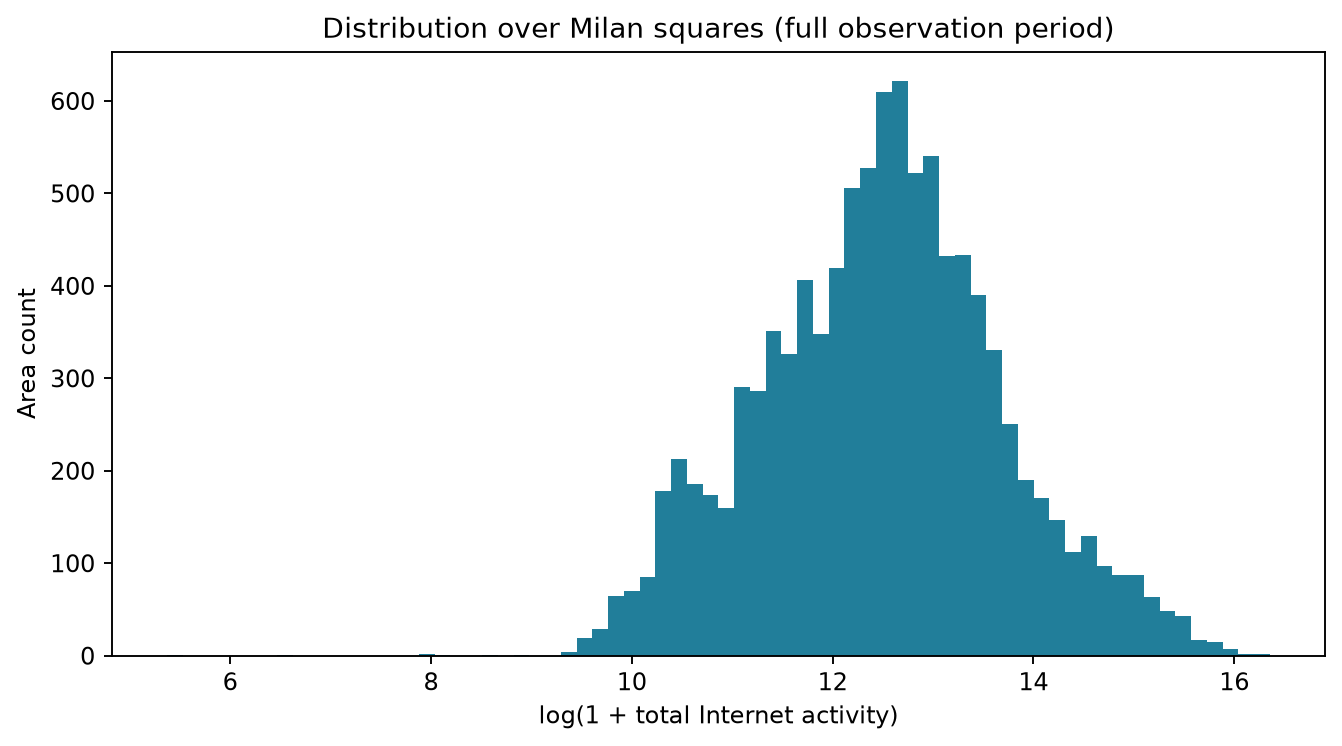

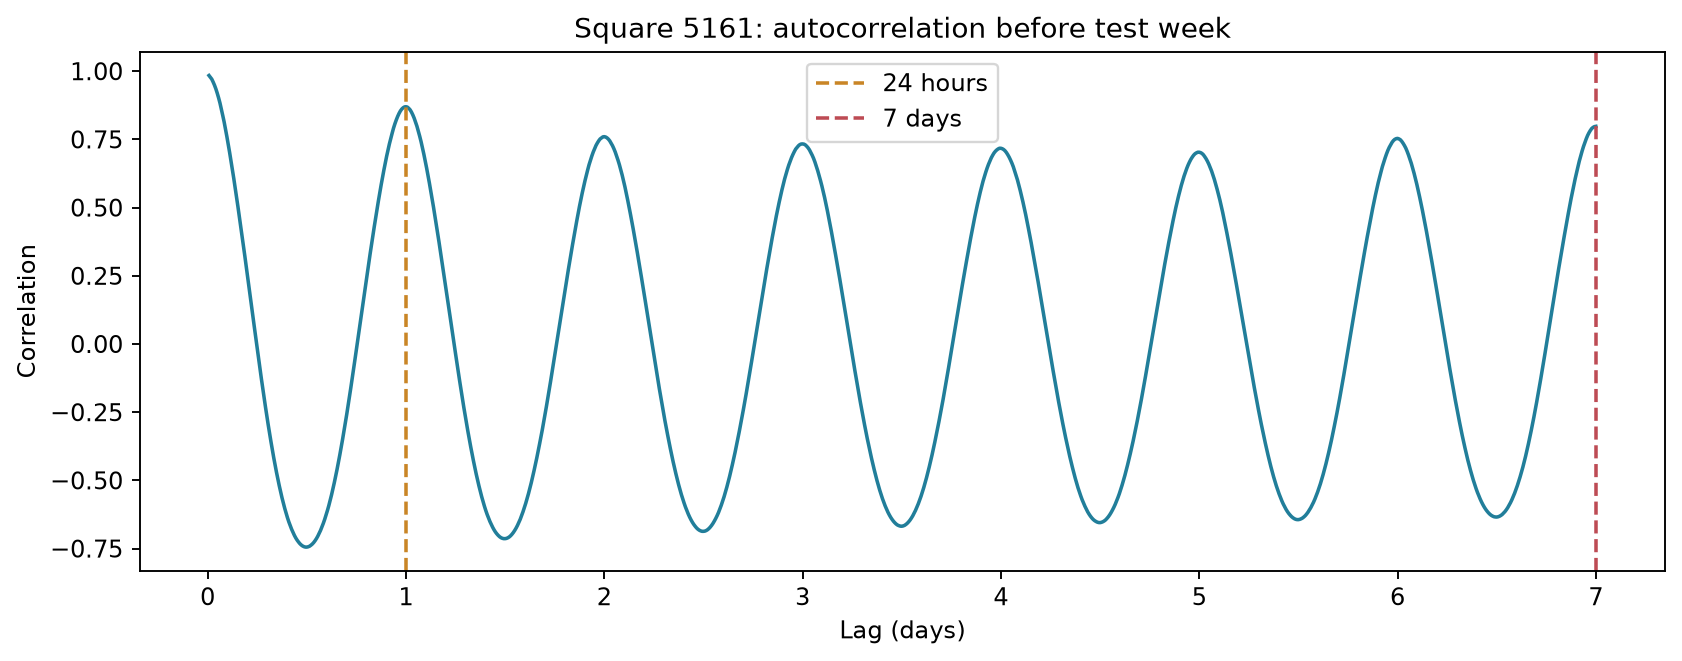

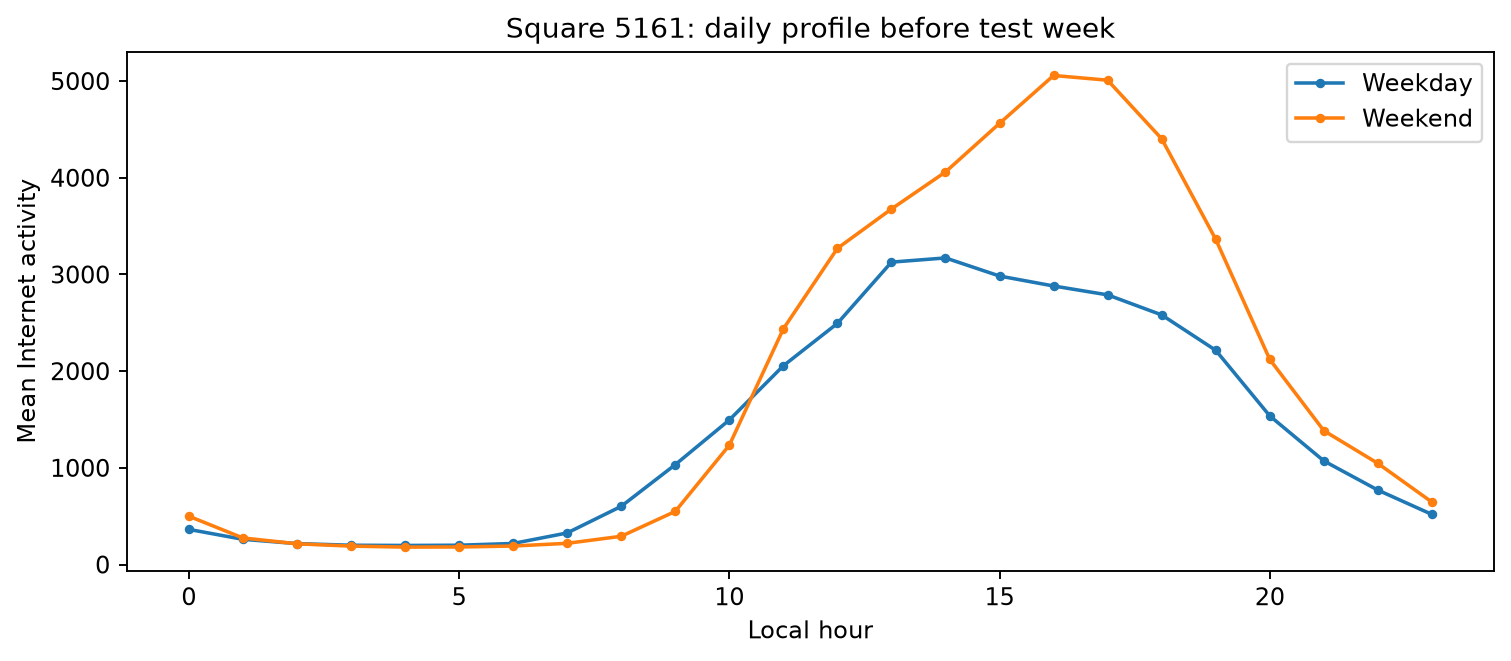

,local_time,actual,ridge,lstm,tcn
0,2013-12-16 00:00:00+01:00,346.460276,357.263292,349.270038,353.229475
1,2013-12-16 00:10:00+01:00,335.479360,337.446623,327.518589,332.498001
2,2013-12-16 00:20:00+01:00,321.910818,316.796135,310.517732,309.582564
3,2013-12-16 00:30:00+01:00,286.600021,315.202834,296.074835,297.962366
4,2013-12-16 00:40:00+01:00,299.662213,293.642709,278.150085,274.536342


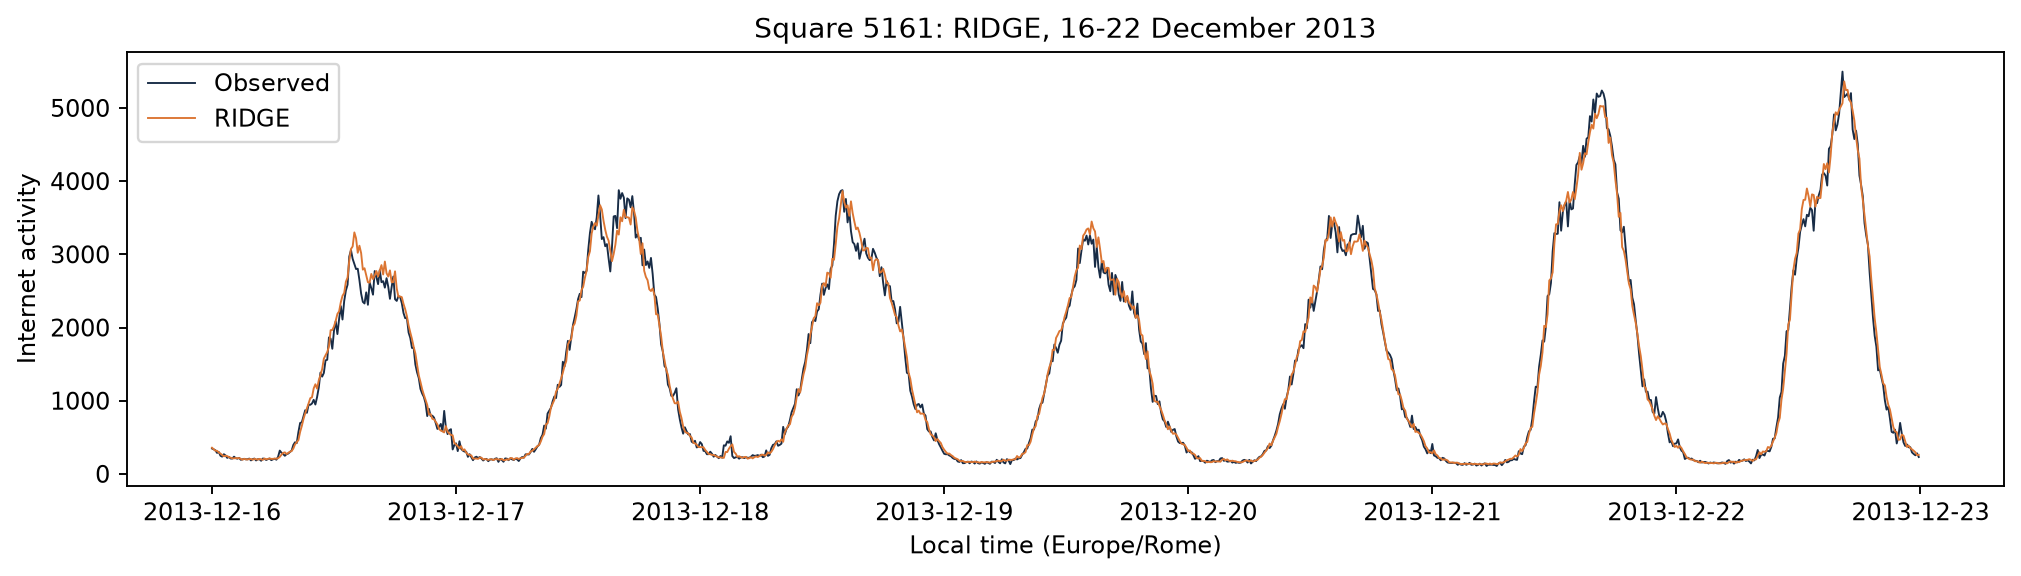

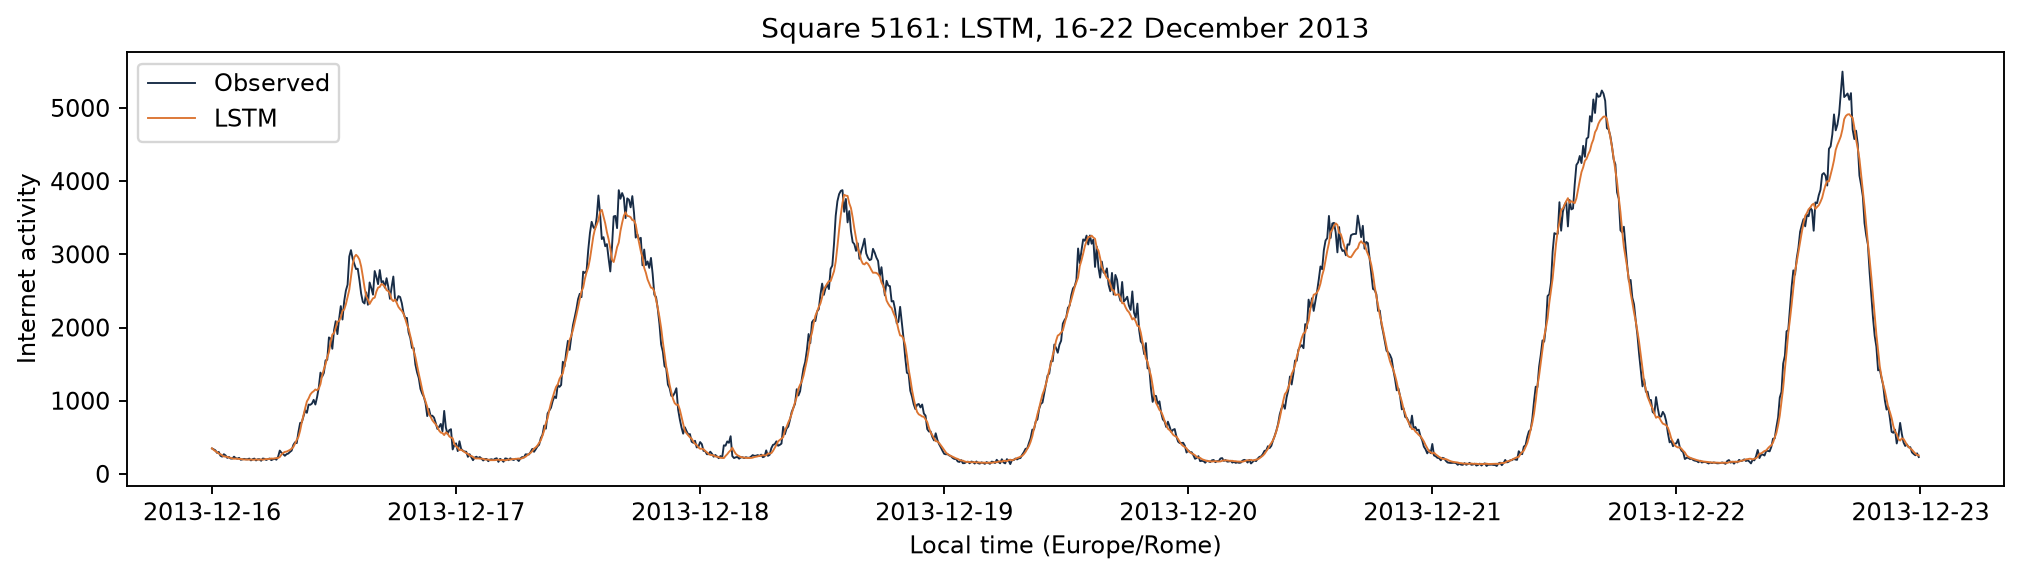

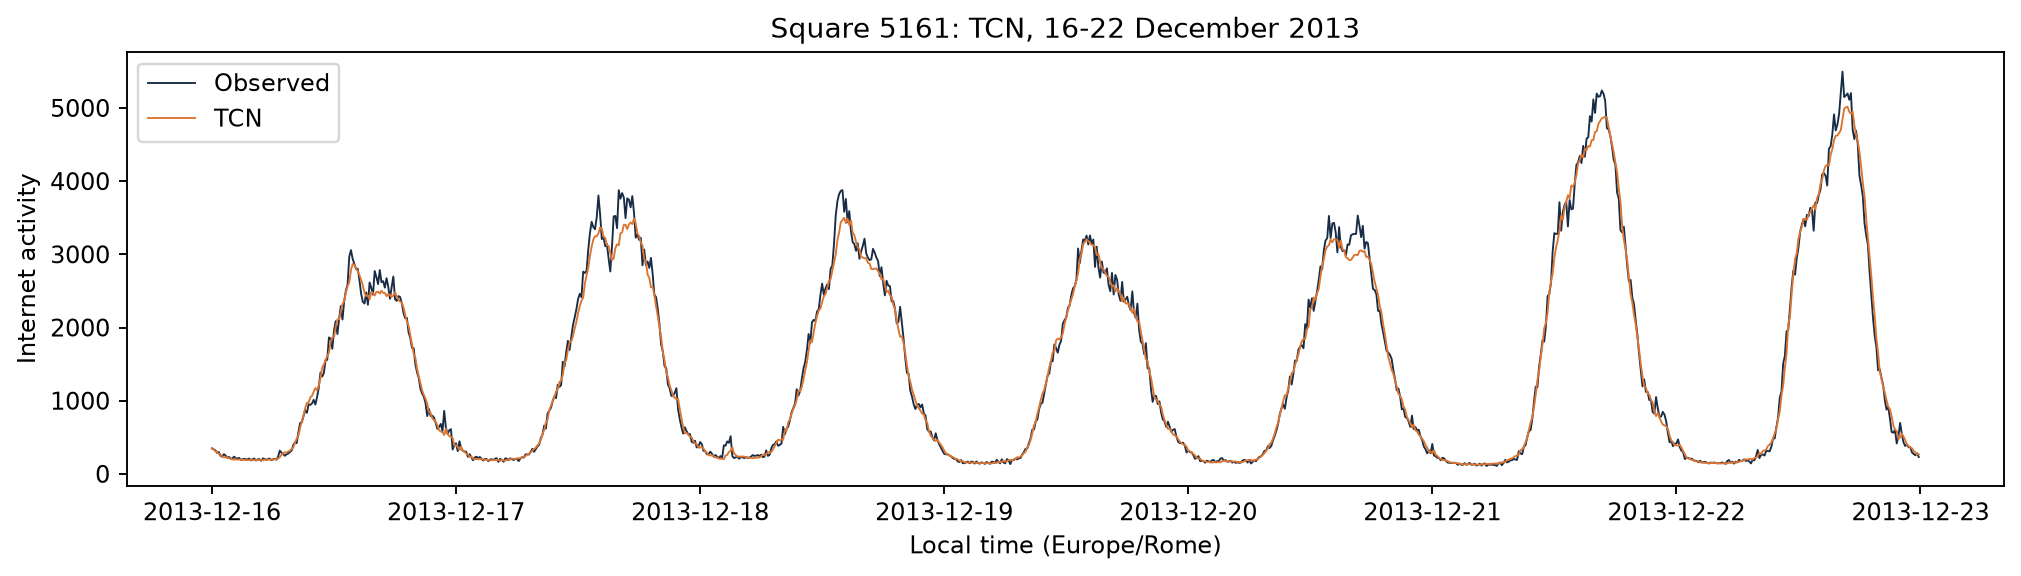

In [5]:
if (PROCESSED / "manifest.json").exists():
    for name in ["area_distribution.png", "top_area_acf.png", "top_area_daily_profile.png"]:
        path = FIGURES / name
        if path.exists():
            display(Image(filename=str(path)))
if (RESULTS / "results.csv").exists():
    area = int(scores.iloc[0].area)
    prediction = pd.read_csv(RESULTS / f"predictions_area_{area}.csv")
    display(prediction.head())
    for model in ["ridge", "lstm", "tcn"]:
        path = FIGURES / f"forecast_{model}_area_{area}.png"
        if path.exists():
            display(Image(filename=str(path)))